# DX 702 (Mod 6): Homework Reflections, 5-8

<font color='plum'> ANSWERS IN THIS COLOR

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm # For linear regression
import statsmodels.formula.api as smf
from sklearn.neighbors import NearestNeighbors

## Homework Reflection 5

### 5.1. Draw a diagram for the following *negative feedback* loop:

        Sweating causes body temperature to decrease.  High body temperature causes sweating.

A negative feedback loop means that one thing increases another while the second thing decreases the first.

Remember that we are using **directed acyclic graphs** where two things cannot directly cause each other.


#### <font color='plum'> ANSWER

`Body Temperature → Sweating → Cooling Effect → Body Temperature (indirectly)`

<font color='plum'>Body Temperature → Sweating
(High temperature triggers sweating)

Sweating → Cooling Effect
(Sweating leads to cooling)

Cooling Effect → Body Temperature
(Cooling reduces body temperature)

![DAG_negative feedback loop.jpeg](<attachment:DAG_negative feedback loop.jpeg>)
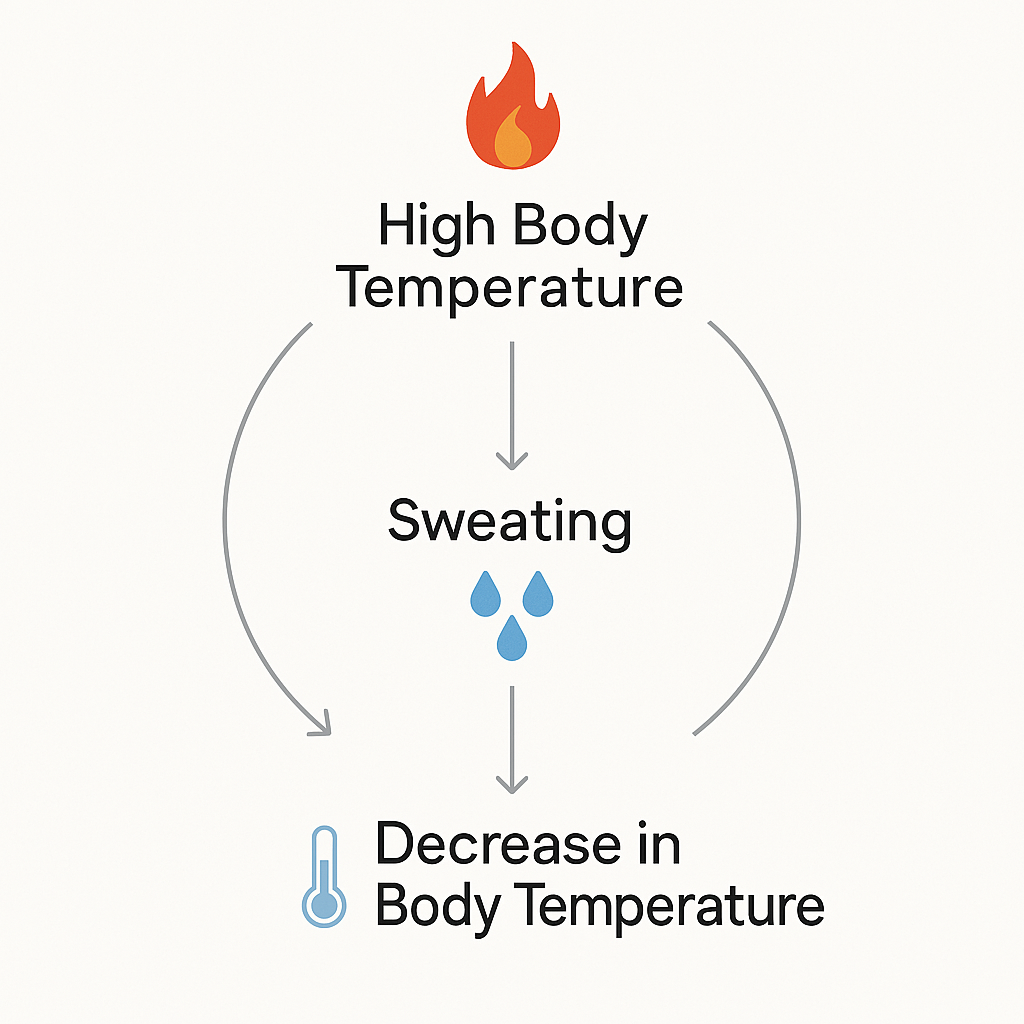

### 5.2. Describe an example of a *positive feedback* loop.  
This means that one thing increases another while the second thing also increases the first.


#### <font color='plum'> ANSWER

Loop: Social Media Engagement 


* Increased user engagement (likes, comments, shares) -->  more content visibility.

* More visibility attracts more users and interactions.
* This, in turn, leads to even more engagement.


`Engagement → Visibility → More Engagement`

### 5.3.1. Draw a diagram for the following situation:

        Lightning storms frighten away deer and bears, decreasing their population, and cause flowers to grow, increasing their population.
        Bears eat deer, decreasing their population.
        Deer eat flowers, decreasing their population.


<font color= 'plum'> I used Claude Sonnet to generaph the diagram below:

![alt text](ecosystem_diagram.svg)

<font color='plum'>
Variables

- Lightning storms: affects all other populations.
- Deer population: Decreases with lightning and bear presence.
- Bear population: Decreases with lightning.
- Flower population: Increases with lightning, decreases with deer.

### 5.3.2 Write a dataset that simulates this situation.  (Show the code.) Include noise / randomness in all cases.

In [2]:

np.random.seed(42)

num_samples = 1000

noise1 = np.random.normal(0, 5, num_samples)
noise2 = np.random.normal(0, 4, num_samples)
noise3 = np.random.normal(0, 10, num_samples)

# Simulate  data
lightning    = np.random.normal(5, 2, num_samples)
deer_pop     = np.random.normal(50, 10, num_samples) - (0.5 * lightning) + noise1
bear_pop     = np.random.normal(30, 8, num_samples) - (0.3 * lightning) + noise2
flower_pop   = np.random.normal(100, 20, num_samples) + (0.7 * lightning) - (0.4 * deer_pop) + noise3

# Bears eat deer, decreasing their population
deer_pop -= 0.2 * bear_pop

# Deer eat flowers, decreasing their population
flower_pop -= 0.3 * deer_pop

In [3]:
df = pd.DataFrame({
    'lightning_storms': lightning,
    'deer_population': deer_pop,
    'bear_population': bear_pop,
    'flower_population': flower_pop
})

df.head(n=10)

,lightning_storms,deer_population,bear_population,flower_population
0,1.184385,36.886037,31.852029,43.427272
1,3.279230,41.539538,29.087453,56.826985
2,4.172789,48.407909,14.621539,41.100290
3,8.775375,53.525981,22.138919,52.863931
4,6.113106,24.739778,36.821594,60.796450
5,2.329037,49.454195,20.681374,84.233906
6,5.972073,19.830709,40.177012,80.673667
7,1.905392,39.411378,35.871268,30.992708
8,7.165382,33.952253,26.174730,108.549026
9,4.057751,51.915294,25.509497,57.092859


### 5.3.3 Identify a backdoor path with one or more confounders for the relationship between deer and flowers.

<font color='plum'>

The bear population affects both deer and flowers; if we don't control for it, it will potentially bias our estimated effect of deer on flowers. So:


`deer_pop <-- bear_pop --> flower_pop`


Confounder: `bear_pop`




### 5.4. Draw a diagram for a situation of your own invention.  
The diagram should include at least four nodes, one confounder, and one collider.  Be sure that it is acyclic (no loops).  
    Which node would you say is most like a treatment (X)?  
    
Which is most like an outcome (Y)?


#### <font color='plum'>  ANSWER 

Exercise and Mental Health, Causal Diagram

![alt text](../DAG_exercise.svg)


--------------------------------------------------
## Homework Reflection 6

### 6.1. What is a potential problem with computing the Marginal Treatment Effect simply by comparing each untreated item to its counterfactual and taking the maximum difference?  

(Hint: think of statistics here.  Consider that only the most extreme item ends up being used to estimate the MTE.  That's not necessarily a bad thing; the MTE is supposed to come from the untreated item that will produce the maximum effect.  But there is nevertheless a problem.)

Possible answer: We are likely to find the item with the most extreme difference, which may be high simply due to randomness.
(Please explain / justify this answer, or give a different one if you can think of one.)


<font color='plum'>

#### ANSWER 
Finding the item with the most extreme difference will likely be misleading due to randomness. If we compute the Marginal Treatment Effect by simply taking the max observed difference, we systematically select the observation that is most likely to be an overestimate due to random chance. As a result, we introduce selection bias and confuse Estimated Effect with True Effect. 


When we take the maximum difference, we are not just finding the item with the highest *true* effect. We are finding the item that has the largest combination of a high true effect **and** a large, positive random error.


`Estimated Effect = True Effect + Random Error`


So, the potential problem is that this method yields upwardly biased estimates of the true MTE. We are capturing the effect of randomness and mistaking it for treatment efficacy. 

### 6.2. Propose a solution that remedies this problem and write some code that implements your solution.  

It's very important here that you clearly explain what your solution will do.


Possible answer: maybe we could take the 90th percentile of the treatment effect and use it as a proxy for the Marginal Treatment Effect.
(Either code this answer or choose a different one.)



#### <font color='plum'> ANSWER

<font color='plum'> Proxying the MTE by using the 90th percentile of the treatment effect is kind of arbitrary. Yes it will reduce selection bias but might actually understate the true MTE.

PROPOSAL:  <font color = 'cyan'>JACKKNIFE CORRECTION. </font> (Primarily because it sounds kind of cool)
1. Compute n different leave-one-out maxima. So for each of the n observations, compute the max treatment effect excluding that observation
2. Compute the average of the leave-one-out maxima and compare to original maxima. The difference is how much the original max was inflated by selecting extreme values.
3. Correct for bias. 
    * `bias_estimate = (n - 1) * (avg_jackknife_max - original_max)`
    * `Adjusted MTE = original_max - bias_estimate`

In [4]:
## using the data from homework_6.1.csv  

df_6 = pd.read_csv('https://raw.githubusercontent.com/joshua-vonkorff/2025-summer-mod-6/main/homework_6.1.csv')
df_6.drop(columns=['Unnamed: 0'], inplace = True)
print(df_6.info())
df_6.head(n = 10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Z       1000 non-null   float64
 1   X       1000 non-null   int64  
 2   Y       1000 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 23.6 KB
None


,Z,X,Y
0,0.548814,0,-0.823220
1,0.715189,1,0.842405
2,0.602763,1,0.898618
3,0.544883,0,-0.817325
4,0.423655,0,-0.635482
5,0.645894,0,-0.968841
6,0.437587,0,-0.656381
7,0.891773,1,0.754113
8,0.963663,1,0.718169
9,0.383442,1,1.008279


In [5]:

# Separate into treated and untreated groups
treated_df      = df_6[df_6['X'] == 1].reset_index(drop=True)
untreated_df    = df_6[df_6['X'] == 0].reset_index(drop=True)

# Reshape confounder data for NearestNeighbors
Z_treated   = treated_df[['Z']]
Z_untreated = untreated_df[['Z']]

# --- ATU Calculation ---
# Find nearest treated neighbor for each untreated subject
nn_treated = NearestNeighbors(n_neighbors=1, algorithm='auto').fit(Z_treated)
distances_atu, indices_atu = nn_treated.kneighbors(Z_untreated)

# outcomes of  matched treated subjects
y_counterfactual_atu = treated_df.loc[indices_atu.flatten(), 'Y'].values

# individual effects for the untreated
effects_for_untreated = y_counterfactual_atu - untreated_df['Y'].values

# original MTE
original_mte = effects_for_untreated.max()

# --- Jackknife Correction for MTE ---
n = len(effects_for_untreated)
jackknife_mtes = []

# Leave-one-out MTEs
for i in range(n):
    loo_effects     = np.delete(effects_for_untreated, i)
    jackknife_mtes.append(loo_effects.max())

# average of jackknife MTEs
avg_jackknife_mte = np.mean(jackknife_mtes)

# Estimate bias
bias_estimate = (n - 1) * (avg_jackknife_mte - original_mte)

# Corrected MTE
corrected_mte = original_mte - bias_estimate

print(f"Original MTE: {original_mte}")
print(f"Bias Estimate: {bias_estimate}")
print(f"Bias-Corrected MTE: {corrected_mte}")



Original MTE: 2.1724698851117035
Bias Estimate: -0.01651478500558312
Bias-Corrected MTE: 2.1889846701172866


-----------------------------------------------------
## Homework Reflection 7

### 7.1. Create a linear regression model involving a confounder that is left out of the model. 
 
 - Show whether the true correlation between X and Y is overestimated, underestimated, or neither.
 
 - Explain in words why this is the case for the given coefficients you have chosen.


#### <font color='plum'> ANSWER

In [6]:

df_7 = pd.read_csv('https://raw.githubusercontent.com/joshua-vonkorff/2025-summer-mod-6/main/homework_7.1.csv')
df_7.drop(columns=['Unnamed: 0'], inplace = True)
print(df_7.info())
# df_7.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       10000 non-null  float64
 1   W       10000 non-null  float64
 2   Z       10000 non-null  float64
 3   Y       10000 non-null  float64
dtypes: float64(4)
memory usage: 312.6 KB
None


In [7]:

# Model 1: Regress Y on X only (omitting confounder Z)
X1      = sm.add_constant(df_7[['X']])
model1  = sm.OLS(df_7['Y'], X1).fit()

# Model 2: Regress Y on X and Z (including confounder)
X2      = sm.add_constant(df_7[['X', 'Z']])
model2 = sm.OLS(df_7['Y'], X2).fit()

# Extract coefficients of X from both models
coef_X_model1 = model1.params['X']
coef_X_model2 = model2.params['X']

print(f"Coefficient of X without Z (omitted confounder): {coef_X_model1:.4f}")
print(f"Coefficient of X with Z included: {coef_X_model2:.4f}")

# Determine whether the effect is overestimated or underestimated
if coef_X_model1 > coef_X_model2:
    conclusion = "overestimated"
elif coef_X_model1 < coef_X_model2:
    conclusion = "underestimated"
else:
    conclusion = "neither overestimated nor underestimated"

print(f"\nConclusion: The effect of X on Y is {conclusion} when Z is omitted.")



Coefficient of X without Z (omitted confounder): 2.0180
Coefficient of X with Z included: 2.0162

Conclusion: The effect of X on Y is overestimated when Z is omitted.


<font color = 'plum'>  The confounder Z influences both treatment (X) and outcome (Y). If Z is omitted, the model compensates by attributing the variation in Y (originally explained by Z) to X. Consequently, the effect of X on Y is overestimated in the absence of the confounder. 

### 7.2. Perform a linear regression analysis in which one of the coefficients is zero, e.g.:

        W = [noise]
        X = [noise]
        Y = 2 * X + [noise]


- Next, compute the **p-value of a coefficient** - in this case, the *coefficient of W*.  (This is the likelihood that the estimated coefficient would be as high or low as it is, given that the actual coefficient is zero.) If the p-value is less than 0.05, this ordinarily means that we judge the coefficient to be nonzero (incorrectly, in this case.)

- Run the analysis 1000 times and report the best (smallest) p-value.
  
- If the p-value is less than 0.05, does this mean the coefficient actually is nonzero?  What is the problem with repeating the analysis?

<font color='plum'> p-Hacking and the MULTIPLE COMPARISONS Problem

Smallest p-value for W across 1000 simulations: 0.000475


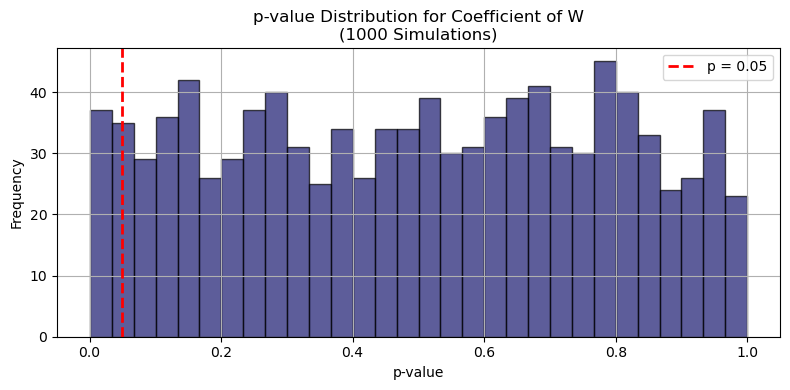

In [8]:

np.random.seed(42)

# Parameters
n_samples     = 100  # number of samples per simulation
n_simulations = 1000
min_p_value   = 1.0  # initialize with the maximum possible p-value
p_values      = []  # to store p-values from each simulation

for _ in range(n_simulations):
    # Generate independent noise variables
    W       = np.random.normal(0, 1, n_samples)
    X       = np.random.normal(0, 1, n_samples)
    noise   = np.random.normal(0, 1, n_samples)

    # Y as a function of X only
    Y       = 2 * X + noise
    
    # Create design matrix with constant, W and X
    X_design = sm.add_constant(np.column_stack((W, X)))
    
    # Fit  model
    model   = sm.OLS(Y, X_design).fit()
    
    # Get p-value for the coefficient of W (index 1)
    p_value_W = model.pvalues[1]
    p_values.append(p_value_W)

    # Update minimum p-value if current one is smaller
    if p_value_W < min_p_value:
        min_p_value = p_value_W

# Report smallest p-value observed
print(f"Smallest p-value for W across {n_simulations} simulations: {min_p_value:.6f}")

plt.figure(figsize=(8, 4))
plt.hist(p_values, bins=30, edgecolor='black', color='midnightblue', alpha=0.7)
plt.axvline(0.05, color='red', linestyle='dashed', linewidth=2, label='p = 0.05')
plt.title(f'p-value Distribution for Coefficient of W\n({n_simulations} Simulations)')
plt.xlabel('p-value')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<font color = 'plum'> The smallest p-value from 1000 tests won't tell us whether there's a real effect - if we run many tests, we will find statistically significant results purely by chance. 

-------------------------------------------------
## Homework Reflection 8

### 8.1. Include the code you used to solve the two coding quiz problems and write about the obstacles / challenges / insights you encountered while solving them.